In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth, association_rules


In [10]:
training_df=pd.read_csv("../Datasets/training_df.csv")
training_df.fillna(0,inplace=True)
training_df.drop(['date','time'],axis=1,inplace=True)
training_df

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,...,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,fire
0,10.460000,95.428820,9.7600,9.326071,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.760000,13.110001,14.010000,21.910000,0.275,0.318,0.195,0.026,1
1,10.453500,95.428590,9.7535,9.317741,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.753500,13.103500,14.003500,21.903500,0.275,0.318,0.195,0.026,1
2,10.414500,95.427210,9.7145,9.267784,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.714500,13.064501,13.964500,21.864500,0.275,0.318,0.195,0.026,1
3,9.223500,99.663920,9.1735,8.143780,0.0,0.0,0.0,0.0,0.0,1012.5,...,13.320000,10.423500,12.823500,13.723500,21.923500,0.273,0.324,0.201,0.020,1
4,9.243000,99.663990,9.1930,8.168585,0.0,0.0,0.0,0.0,0.0,1012.5,...,13.320000,10.443000,12.842999,13.743000,21.942999,0.273,0.324,0.201,0.020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113891,28.476500,26.921050,7.6265,26.616827,0.0,0.0,0.0,0.0,1.0,1015.9,...,38.160000,41.726498,30.776499,26.726500,18.426498,0.042,0.134,0.192,0.235,0
113892,25.435000,36.749325,9.5850,24.854360,0.0,0.0,0.0,0.0,0.0,1009.1,...,17.640000,32.185000,28.734999,23.435000,17.535000,0.135,0.170,0.229,0.293,0
113893,13.914001,82.397710,10.9640,13.423975,0.0,0.0,0.0,0.0,3.0,1012.1,...,18.720000,14.164001,13.364000,12.314000,12.314000,0.231,0.314,0.330,0.342,0
113894,7.604000,52.525845,-1.4960,4.411881,0.0,0.0,0.0,0.0,0.0,1017.0,...,18.720000,10.654000,14.604001,13.604000,7.954000,0.270,0.296,0.347,0.392,0


In [11]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113896 entries, 0 to 113895
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   temperature_2m                 113896 non-null  float64
 1   relative_humidity_2m           113896 non-null  float64
 2   dew_point_2m                   113896 non-null  float64
 3   apparent_temperature           113896 non-null  float64
 4   precipitation                  113896 non-null  float64
 5   rain                           113896 non-null  float64
 6   snowfall                       113896 non-null  float64
 7   snow_depth                     113896 non-null  float64
 8   weather_code                   113896 non-null  float64
 9   pressure_msl                   113896 non-null  float64
 10  surface_pressure               113896 non-null  float64
 11  cloud_cover                    113896 non-null  float64
 12  cloud_cover_low               

In [12]:
# Drop target variable ('fire') from independent features
X = training_df.drop(columns=['fire'])
y = training_df['fire']  # Target variable

### STEP 1: AUTOMATIC FEATURE SELECTION ###
# Remove highly correlated features to prevent redundancy
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
highly_correlated = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.85)]


In [13]:
# Drop highly correlated columns
X = X.drop(columns=highly_correlated)

# Select a subset of features to make processing efficient
num_features = min(10, X.shape[1])  # Use up to 10 features (adjustable)
selected_columns = X.columns[:num_features]

print(f"Selected {num_features} features for ARM: {selected_columns.tolist()}")


Selected 10 features for ARM: ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'snowfall', 'snow_depth', 'weather_code', 'pressure_msl', 'surface_pressure', 'cloud_cover']


In [14]:
# Subset dataset with selected columns
df_subset = training_df[selected_columns].copy()
df_subset['fire'] = y  # Keep 'fire' column for association mining

### STEP 2: BINARIZATION (Convert Continuous Data to High/Low) ###
for col in selected_columns:
    median_value = df_subset[col].median()
    df_subset[col] = np.where(df_subset[col] > median_value, f"{col}_High", f"{col}_Low")


In [15]:
# Convert 'fire' to categorical labels
df_subset['fire'] = df_subset['fire'].apply(lambda x: 'fire_Yes' if x == 1 else 'fire_No')

### STEP 3: TRANSACTIONAL FORMAT (One-Hot Encoding) ###
df_encoded = pd.get_dummies(df_subset)

# Limit dataset to a manageable number of rows for performance
num_rows = min(20_000, df_encoded.shape[0])  # Use up to 20,000 rows (adjustable)
df_encoded = df_encoded.sample(n=num_rows, random_state=42)

print(f"Using {num_rows} rows for ARM processing")


Using 20000 rows for ARM processing


In [24]:
df_encoded

,temperature_2m_temperature_2m_High,temperature_2m_temperature_2m_Low,relative_humidity_2m_relative_humidity_2m_High,relative_humidity_2m_relative_humidity_2m_Low,dew_point_2m_dew_point_2m_High,dew_point_2m_dew_point_2m_Low,precipitation_precipitation_High,precipitation_precipitation_Low,snowfall_snowfall_High,snowfall_snowfall_Low,...,weather_code_weather_code_High,weather_code_weather_code_Low,pressure_msl_pressure_msl_High,pressure_msl_pressure_msl_Low,surface_pressure_surface_pressure_High,surface_pressure_surface_pressure_Low,cloud_cover_cloud_cover_High,cloud_cover_cloud_cover_Low,fire_fire_No,fire_fire_Yes
57526,True,False,True,False,True,False,False,True,False,True,...,False,True,False,True,False,True,False,True,True,False
32133,False,True,True,False,True,False,False,True,False,True,...,False,True,True,False,True,False,True,False,False,True
70733,True,False,False,True,False,True,False,True,False,True,...,True,False,True,False,False,True,True,False,True,False
59482,True,False,False,True,False,True,False,True,False,True,...,True,False,True,False,False,True,True,False,True,False
18387,True,False,False,True,False,True,False,True,False,True,...,False,True,False,True,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32546,False,True,True,False,False,True,False,True,False,True,...,False,True,True,False,True,False,False,True,False,True
14613,True,False,False,True,True,False,False,True,False,True,...,False,True,False,True,True,False,False,True,False,True
106498,False,True,True,False,True,False,False,True,False,True,...,False,True,False,True,True,False,True,False,True,False
75208,False,True,False,True,False,True,False,True,False,True,...,False,True,True,False,False,True,False,True,True,False


In [28]:
df_encoded.to_csv("../Datasets/transaction_data.csv", index=False)

In [18]:
### STEP 4: APPLY FP-GROWTH ###
frequent_itemsets = fpgrowth(df_encoded, min_support=0.005, use_colnames=True)

### STEP 5: GENERATE ASSOCIATION RULES ###
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.5)

# Sort rules by different metrics
top_support = rules.sort_values(by="support", ascending=False).head(15)
top_confidence = rules.sort_values(by="confidence", ascending=False).head(15)
top_lift = rules.sort_values(by="lift", ascending=False).head(15)

print("\nTop 15 Rules by Support:\n", top_support)
print("\nTop 15 Rules by Confidence:\n", top_confidence)
print("\nTop 15 Rules by Lift:\n", top_lift)



Top 15 Rules by Support:
                                               antecedents  \
990942  (precipitation_precipitation_Low, cloud_cover_...   
990941  (precipitation_precipitation_Low, cloud_cover_...   
990919                    (dew_point_2m_dew_point_2m_Low)   
990918  (dew_point_2m_dew_point_2m_Low, snowfall_snowf...   
990920  (relative_humidity_2m_relative_humidity_2m_Low...   
990921  (dew_point_2m_dew_point_2m_Low, cloud_cover_cl...   
990915  (relative_humidity_2m_relative_humidity_2m_Low...   
990912  (precipitation_precipitation_Low, cloud_cover_...   
990923  (relative_humidity_2m_relative_humidity_2m_Low...   
990922  (relative_humidity_2m_relative_humidity_2m_Low...   
990927  (relative_humidity_2m_relative_humidity_2m_Low...   
990896  (dew_point_2m_dew_point_2m_Low, snowfall_snowf...   
990897                    (dew_point_2m_dew_point_2m_Low)   
990898  (relative_humidity_2m_relative_humidity_2m_Low...   
990899  (relative_humidity_2m_relative_humidity_2m_Low... 

In [32]:
# Function to display top rules in a structured table format
def display_rules_table(rules, metric, top_n=15):
    sorted_rules = rules.sort_values(by=metric, ascending=False).head(top_n)
    return sorted_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

# Generate tables for each metric
top_support_table = display_rules_table(rules, "support")
top_confidence_table = display_rules_table(rules, "confidence")
top_lift_table = display_rules_table(rules, "lift")

# Display tables in Jupyter Notebook
print("\nTop 15 Rules by Support:")
display(top_support_table)

print("\nTop 15 Rules by Confidence:")
display(top_confidence_table)

print("\nTop 15 Rules by Lift:")
display(top_lift_table)



Top 15 Rules by Support:


,antecedents,consequents,support,confidence,lift
990942,"(precipitation_precipitation_Low, cloud_cover_...","(dew_point_2m_dew_point_2m_Low, weather_code_w...",0.2764,0.787464,1.738140
990941,"(precipitation_precipitation_Low, cloud_cover_...",(relative_humidity_2m_relative_humidity_2m_Low...,0.2764,0.736870,1.658684
990919,(dew_point_2m_dew_point_2m_Low),"(precipitation_precipitation_Low, cloud_cover_...",0.2764,0.552248,1.573355
990918,"(dew_point_2m_dew_point_2m_Low, snowfall_snowf...","(precipitation_precipitation_Low, cloud_cover_...",0.2764,0.552248,1.573355
990920,(relative_humidity_2m_relative_humidity_2m_Low...,(dew_point_2m_dew_point_2m_Low),0.2764,0.787464,1.573355
990921,"(dew_point_2m_dew_point_2m_Low, cloud_cover_cl...",(relative_humidity_2m_relative_humidity_2m_Low...,0.2764,0.736870,1.658684
990915,(relative_humidity_2m_relative_humidity_2m_Low...,"(precipitation_precipitation_Low, dew_point_2m...",0.2764,0.787464,1.575244
990912,"(precipitation_precipitation_Low, cloud_cover_...",(dew_point_2m_dew_point_2m_Low),0.2764,0.787464,1.573355
990923,(relative_humidity_2m_relative_humidity_2m_Low...,"(dew_point_2m_dew_point_2m_Low, snowfall_snowf...",0.2764,0.787464,1.573355
990922,(relative_humidity_2m_relative_humidity_2m_Low...,"(dew_point_2m_dew_point_2m_Low, weather_code_w...",0.2764,0.787464,1.738140



Top 15 Rules by Confidence:


,antecedents,consequents,support,confidence,lift
143566,"(cloud_cover_cloud_cover_Low, snowfall_snowfal...","(weather_code_weather_code_Low, dew_point_2m_d...",0.00505,1.0,2.462145
1042376,"(cloud_cover_cloud_cover_Low, fire_fire_Yes, p...","(weather_code_weather_code_Low, snow_depth_sno...",0.01245,1.0,2.292789
143575,"(cloud_cover_cloud_cover_Low, surface_pressure...","(snowfall_snowfall_Low, dew_point_2m_dew_point...",0.00505,1.0,2.002202
1042208,"(cloud_cover_cloud_cover_Low, fire_fire_Yes, p...","(weather_code_weather_code_Low, snowfall_snowf...",0.01245,1.0,2.292789
1042358,"(cloud_cover_cloud_cover_Low, fire_fire_Yes, p...","(snow_depth_snow_depth_Low, temperature_2m_tem...",0.01245,1.0,2.011870
1042180,"(cloud_cover_cloud_cover_Low, snowfall_snowfal...",(temperature_2m_temperature_2m_High),0.01245,1.0,2.011870
1042183,"(cloud_cover_cloud_cover_Low, snowfall_snowfal...","(weather_code_weather_code_Low, temperature_2m...",0.01245,1.0,2.292789
1511396,"(precipitation_precipitation_Low, snowfall_sno...",(relative_humidity_2m_relative_humidity_2m_Hig...,0.00870,1.0,1.991040
143550,"(cloud_cover_cloud_cover_Low, snow_depth_snow_...","(snowfall_snowfall_Low, dew_point_2m_dew_point...",0.00505,1.0,2.002202
143549,"(cloud_cover_cloud_cover_Low, snowfall_snowfal...","(dew_point_2m_dew_point_2m_High, snow_depth_sn...",0.00505,1.0,2.002202



Top 15 Rules by Lift:


,antecedents,consequents,support,confidence,lift
1350748,"(precipitation_precipitation_Low, fire_fire_Ye...","(dew_point_2m_dew_point_2m_Low, temperature_2m...",0.0066,0.628571,11.727079
1353133,"(precipitation_precipitation_Low, snowfall_sno...","(dew_point_2m_dew_point_2m_Low, temperature_2m...",0.0066,0.628571,11.727079
1352386,"(precipitation_precipitation_Low, fire_fire_Ye...","(dew_point_2m_dew_point_2m_Low, temperature_2m...",0.0066,0.628571,11.727079
1353018,"(precipitation_precipitation_Low, snowfall_sno...","(dew_point_2m_dew_point_2m_Low, temperature_2m...",0.0066,0.628571,11.727079
1353161,"(precipitation_precipitation_Low, fire_fire_Ye...","(dew_point_2m_dew_point_2m_Low, snowfall_snowf...",0.0066,0.628571,11.727079
1352477,"(precipitation_precipitation_Low, fire_fire_Ye...","(dew_point_2m_dew_point_2m_Low, temperature_2m...",0.0066,0.628571,11.727079
1353338,"(precipitation_precipitation_Low, fire_fire_Ye...","(snowfall_snowfall_Low, snow_depth_snow_depth_...",0.0066,0.628571,11.727079
1352006,"(precipitation_precipitation_Low, snowfall_sno...","(dew_point_2m_dew_point_2m_Low, temperature_2m...",0.0066,0.628571,11.727079
1352097,"(precipitation_precipitation_Low, fire_fire_Ye...","(dew_point_2m_dew_point_2m_Low, snowfall_snowf...",0.0066,0.628571,11.727079
1352210,"(dew_point_2m_dew_point_2m_Low, snowfall_snowf...","(precipitation_precipitation_Low, fire_fire_Ye...",0.0066,0.123134,11.727079


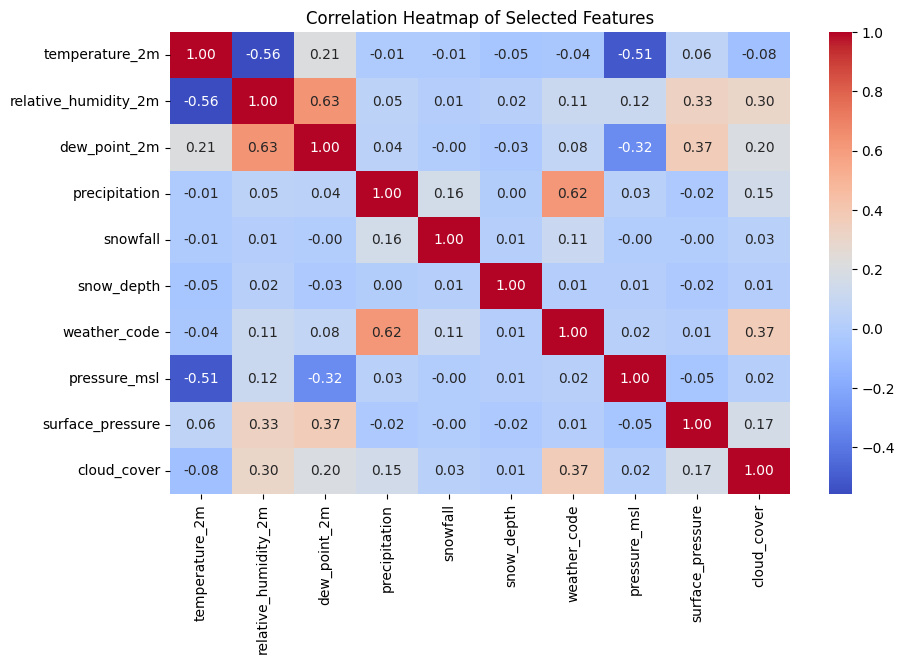

In [20]:
### STEP 6: VISUALIZATION (Heatmap of Feature Correlations) ###
plt.figure(figsize=(10, 6))
sns.heatmap(training_df[selected_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Selected Features")
plt.show()


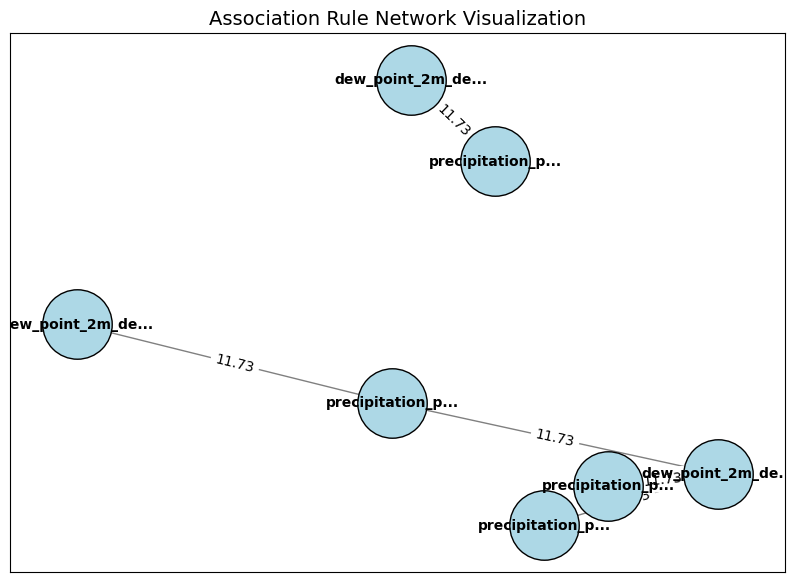

In [27]:
import networkx as nx


# Create a directed graph
G = nx.DiGraph()

# Add edges based on top rules
top_rules = rules.sort_values(by="lift", ascending=False).head(5)

for _, rule in top_rules.iterrows():
    antecedents = ", ".join(rule["antecedents"])
    consequents = ", ".join(rule["consequents"])
    G.add_edge(antecedents, consequents, weight=round(rule["lift"], 2))

# Set layout for better visualization
pos = nx.spring_layout(G, k=1.5)  # Adjust k for better spacing

# Draw nodes
plt.figure(figsize=(10, 7))
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color="lightblue", edgecolors="black")

# Draw edges with thickness based on lift values
edges = G.edges(data=True)
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color="gray", arrows=True)

# Add edge labels (lift values)
edge_labels = {(u, v): d['weight'] for u, v, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# Add node labels (truncate for readability)
node_labels = {node: node[:15] + "..." if len(node) > 15 else node for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_weight="bold")

plt.title("Association Rule Network Visualization", fontsize=14)
plt.show()
